<a href="https://colab.research.google.com/github/Jespinoza-01/FinalProject-IELE756-Group14/blob/main/FinalProyect_Data_A%26P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Anomaly Explanation
**Team members:** Joaquin Espinoza y Antonia Becerra

**GitHub Repository:** https://github.com/Jespinoza-01/FinalProject-IELE756-Group14

## The Anomaly: La Incongruencia Rural en Notificaciones Epidemiológicas
Comunas rurales demográficamente similares presentan un comportamiento de notificación epidemiológica diametralmente opuesto frente a nuestro modelo predictivo. Al aislar los datos espaciales, es altamente sorprendente que, controlando por demografía, la comuna de San Pedro (13505) destruya las predicciones superando masivamente los casos esperados (residuo +9.37), mientras que una comuna periurbana comparable como María Pinto (13504) se ubica en el extremo opuesto, con muchos menos casos de los esperados (residuo -1.25). La demografía no explica su abismal brecha de salud.

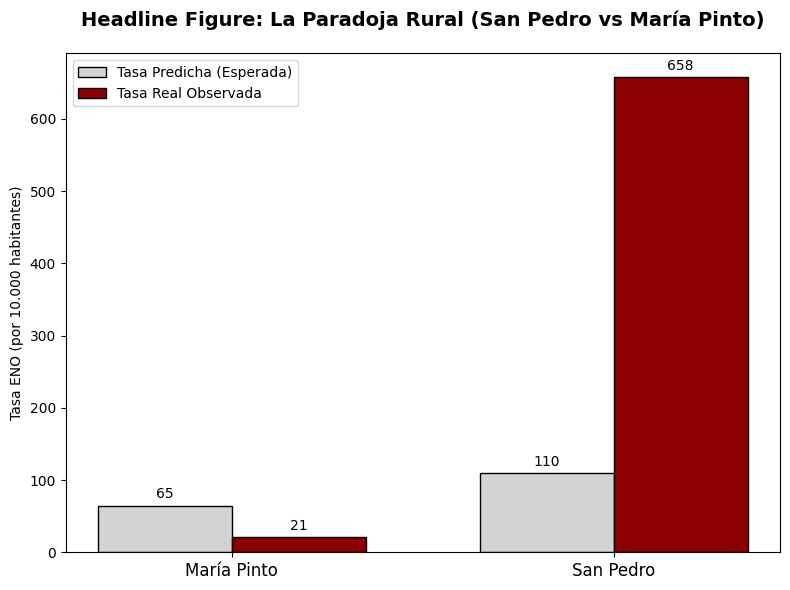

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Isolation Code: Cargar datos pre-computados y regenerar predicciones rápidamente
df = pd.read_csv("tarea3_analytical_table.csv")
df_model = df[df['codigo_comuna'] != 13101].dropna(subset=['eno_total', 'pct_foreign', 'schooling_gap', 'log_pop_total']).copy()

# Ajustar el modelo base (Binomial Negativo)
formula = "eno_total ~ pct_foreign + schooling_gap"
nb_model = smf.negativebinomial(formula=formula, data=df_model, offset=df_model['log_pop_total']).fit(disp=False)

# Extraer tasas reales y predichas (por 10.000 habs)
df_model['predicted_eno_rate'] = (nb_model.predict() / df_model['pop_total']) * 10000
df_model['actual_eno_rate'] = (df_model['eno_total'] / df_model['pop_total']) * 10000

# Aislar las dos comunas de la anomalía
anomalia_df = df_model[df_model['codigo_comuna'].isin([13505, 13504])].copy()
# Agregar nombres para el gráfico
anomalia_df['comuna_nombre'] = anomalia_df['codigo_comuna'].map({13505: 'San Pedro', 13504: 'María Pinto'})

# 2. Headline Figure
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(anomalia_df))
width = 0.35

rects1 = ax.bar(x - width/2, anomalia_df['predicted_eno_rate'], width, label='Tasa Predicha (Esperada)', color='lightgray', edgecolor='black')
rects2 = ax.bar(x + width/2, anomalia_df['actual_eno_rate'], width, label='Tasa Real Observada', color='darkred', edgecolor='black')

ax.set_ylabel('Tasa ENO (por 10.000 habitantes)')
ax.set_title('Headline Figure: La Paradoja Rural (San Pedro vs María Pinto)', pad=20, fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(anomalia_df['comuna_nombre'], fontsize=12)
ax.legend()

# Añadir etiquetas de valor
ax.bar_label(rects1, fmt='%.0f', padding=3)
ax.bar_label(rects2, fmt='%.0f', padding=3)

plt.tight_layout()
plt.savefig('figs/headline.png', dpi=300)
plt.show()

### Alternative Check 1: ¿Son realmente similares demográficamente?
Lo que mostraría si fuera cierto: Si la anomalía es solo un artefacto de diferencias poblacionales ocultas, San Pedro debería tener indicadores socioeconómicos o migratorios drásticamente peores que María Pinto.

Lo que realmente mostró: Los datos revelan que no son idénticas. San Pedro tiene una proporción de migrantes cinco veces mayor que María Pinto (11.34% vs 2.08%). Sin embargo, como nuestro modelo matemático ya controla por esta variable (pct_foreign) y aún así arroja un residuo altísimo, confirmamos que la demografía por sí sola es incapaz de explicar la enorme brecha en las notificaciones.

In [2]:
print("--- Check 1: Comparativa Demográfica ---")
comparativa_demo = anomalia_df[['comuna_nombre', 'pct_foreign', 'schooling_gap', 'pop_total']]
display(comparativa_demo.round(2))

--- Check 1: Comparativa Demográfica ---


,comuna_nombre,pct_foreign,schooling_gap,pop_total
44,María Pinto,2.08,-0.86,15352.0
45,San Pedro,11.34,0.08,11108.0


### Alternative Check 2: ¿Es un colapso de salud generalizado o un sesgo de reporte ENO?
Lo que mostraría si fuera cierto: Si San Pedro es un foco de enfermedad extrema (ej. contaminación agrícola grave), sus tasas de hospitalización (GRD) también deberían estar disparadas.

Lo que realmente mostró: Ambas comunas tienen tasas de hospitalización general (GRD) sorprendentemente similares (1.219 vs 1.096 por cada 10.000 habitantes). Esto demuestra que San Pedro no es una comuna "más enferma" en términos de gravedad hospitalaria. La anomalía es exclusiva de la atención primaria/ambulatoria (ENO).

In [3]:
print("--- Check 2: Tasas de Hospitalización GRD ---")
anomalia_df['actual_grd_rate'] = (anomalia_df['grd_total'] / anomalia_df['pop_total']) * 10000
comparativa_salud = anomalia_df[['comuna_nombre', 'actual_eno_rate', 'actual_grd_rate']]
display(comparativa_salud.round(2))

--- Check 2: Tasas de Hospitalización GRD ---


,comuna_nombre,actual_eno_rate,actual_grd_rate
44,María Pinto,20.84,1096.27
45,San Pedro,658.08,1219.84


###  Conclusión

La incongruencia entre San Pedro y María Pinto demuestra que la geografía y la infraestructura de salud importan tanto como la demografía. El hecho de que ambas comunas se hospitalicen a tasas casi idénticas, pero San Pedro notifique 30 veces más eventos ENO (658 vs 20), nos deja con dos conclusiones contundentes: o San Pedro enfrenta brotes agudos y localizados que se resuelven en atención primaria (ej. zoonosis o exposición a agroquímicos), o María Pinto sufre de un grave "sub-registro por derivación", donde sus habitantes se diagnostican en comunas metropolitanas vecinas, invisibilizando su verdadera carga de morbilidad. Planificar políticas de salud basándose solo en variables sociodemográficas dejará a estas realidades territoriales completamente a oscuras.